# VOS (Video Object Segmentation)

It is an important technology in the field of computer vision. Its core task is to accurately and frame-by-frame separate a specific target of interest (e.g., a person, a car) from the background in a video.

This technology is mainly divided into three categories, with the core difference being **how much information the user needs to provide**:

- **Semi-supervised VOS (Most Mainstream):** You only need to provide a **complete annotation of the first frame of the video** (tell the algorithm which pixels belong to the target in the first frame). The algorithm then automatically segments all subsequent frames. It is commonly used in video editing and autonomous driving.
- **Interactive VOS:** You indicate the target using **mouse clicks, scribbles, or brush strokes**. It allows you to make corrections at any time, making it ideal for scenarios requiring high precision with iterative adjustments (e.g., post-production rotoscoping in films).
- **Unsupervised VOS:** The algorithm **does not require any initial target information** from the user. It automatically identifies and segments the **primary foreground objects** within the video.

In terms of technological development, early algorithms (e.g., **OSVOS**) needed to be retrained on each new video, which was very slow. In contrast, **memory-based approaches** using spatio-temporal memory networks have become the mainstream. Simply put, these methods act as if they have a "memory" — they store the segmentation results from previous frames to guide the segmentation of the current frame, achieving significant breakthroughs in both accuracy and speed.

If you want to get hands-on, **interactive tools** are best for experimentation:
- **Recommended Tool:** **X-AnyLabeling**, which is based on the latest **SAM 2** model.
- **Workflow:** You simply use your mouse to draw a bounding box or click on the target you want to segment. The algorithm then automatically tracks and "cuts out" that target throughout the entire video. If the result isn't perfect, you can click on the error frame to make a correction.


# An Example(simulation)

## Main Execution Flow
Open video → Read first frame

Detect initial objects → detect_balls_by_color(first_frame)

Initialize tracker → tracker.initialize_from_masks(first_frame, masks, colors)

Process frame-by-frame:

Frame 0: Use initial masks

Subsequent frames: Call tracker.update(frame) to get new masks

Visualize → visualize_tracking(frame, masks, colors)

Output video → Write to output_tracked.mp4

## Simplification Notes
Real VOS: Deep learning + pixel-level dense matching

This simulation: Bounding box tracking + color-based foreground extraction (demonstrates same workflow)

In [3]:
"""
Simple VOS Simulator for Learning Purposes
===========================================
This demonstrates the CORE IDEA of VOS without complex installations:
1. First frame: User/algorithm provides object masks
2. Subsequent frames: Tracking algorithm follows the objects

Uses only OpenCV (already installed) and numpy.
"""

import cv2
import numpy as np


class SimpleVOStracker:
    """
    A simplified VOS tracker for learning the concept.
    Uses OpenCV's CSRT tracker (works well for rigid objects like balls).
    
    Key insight: Real VOS uses deep learning for pixel-perfect masks.
    This version uses bounding boxes + morphological operations to
    demonstrate the same workflow.
    """
    
    def __init__(self):
        self.trackers = {}      # obj_id -> OpenCV tracker
        self.prev_masks = {}    # obj_id -> last known mask
        self.object_colors = {} # obj_id -> color for visualization
        self.prev_frame = None  # Store previous frame for motion detection
        
    def get_tracker(self):
        """Get CSRT tracker with compatibility for different OpenCV versions."""
        try:
            # Try new OpenCV version (4.5.1+)
            return cv2.legacy.TrackerCSRT_create()
        except AttributeError:
            try:
                # Try old OpenCV version
                return cv2.TrackerCSRT_create()
            except AttributeError:
                # Fallback to KCF tracker
                print("CSRT not available, using KCF tracker instead")
                try:
                    return cv2.legacy.TrackerKCF_create()
                except:
                    return cv2.TrackerKCF_create()
    
    def initialize_from_masks(self, frame, masks, obj_colors):
        """
        Initialize trackers using first-frame masks.
        
        Args:
            frame: BGR image
            masks: dict {obj_id: binary_mask}
            obj_colors: dict {obj_id: (B, G, R)}
        """
        self.object_colors = obj_colors
        self.prev_frame = frame.copy()
        
        for obj_id, mask in masks.items():
            # Get bounding box from mask
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                x, y, w, h = cv2.boundingRect(contours[0])
                bbox = (x, y, w, h)
                
                # Create tracker with compatibility fix
                tracker = self.get_tracker()
                tracker.init(frame, bbox)
                self.trackers[obj_id] = tracker
                self.prev_masks[obj_id] = mask.copy()
                
        print(f"Initialized {len(self.trackers)} trackers")
        
    def update(self, frame):
        """
        Update all trackers and generate masks.
        
        Real VOS uses pixel-level dense matching via neural networks.
        This uses bounding boxes + simple foreground extraction.
        """
        masks = {}
        
        for obj_id, tracker in self.trackers.items():
            success, bbox = tracker.update(frame)
            
            if success:
                x, y, w, h = [int(v) for v in bbox]
                
                # Clamp bounding box to frame boundaries
                h_frame, w_frame = frame.shape[:2]
                x = max(0, min(x, w_frame - 1))
                y = max(0, min(y, h_frame - 1))
                w = min(w, w_frame - x)
                h = min(h, h_frame - y)
                
                if w > 0 and h > 0:
                    # Create mask based on bounding box
                    mask = self._extract_foreground(frame, (x, y, w, h), obj_id)
                    masks[obj_id] = mask
                else:
                    masks[obj_id] = self.prev_masks.get(obj_id, np.zeros(frame.shape[:2], dtype=np.uint8))
            else:
                # Tracker lost: use previous mask
                masks[obj_id] = self.prev_masks.get(obj_id, np.zeros(frame.shape[:2], dtype=np.uint8))
                
        self.prev_masks = masks
        self.prev_frame = frame.copy()
        return masks
    
    def _extract_foreground(self, frame, bbox, obj_id):
        """
        Extract foreground mask within bounding box.
        Uses color similarity to previous frame's mask color.
        """
        x, y, w, h = bbox
        h_frame, w_frame = frame.shape[:2]
        
        # Ensure bounding box is within frame boundaries
        x = max(0, min(x, w_frame - 1))
        y = max(0, min(y, h_frame - 1))
        w = min(w, w_frame - x)
        h = min(h, h_frame - y)
        
        mask = np.zeros((h_frame, w_frame), dtype=np.uint8)
        
        if w <= 0 or h <= 0:
            return mask
        
        # Get region of interest
        roi = frame[y:y+h, x:x+w]
        
        # If we have previous mask, use its average color for matching
        prev_mask = self.prev_masks.get(obj_id, None)
        
        if prev_mask is not None:
            # Get the previous mask region corresponding to this bounding box
            prev_mask_roi = prev_mask[y:y+h, x:x+w]
            
            # Only proceed if there are foreground pixels in previous mask
            if np.any(prev_mask_roi > 0):
                # Compute average color of the object from previous frame
                # Need to ensure both roi and prev_mask_roi have same dimensions
                if roi.shape[:2] == prev_mask_roi.shape[:2]:
                    # Calculate weighted average color (only where mask is >0)
                    masked_pixels = roi[prev_mask_roi > 0]
                    if len(masked_pixels) > 0:
                        avg_color = np.mean(masked_pixels, axis=0)
                        
                        # Color distance threshold (smaller = more strict)
                        diff = np.sqrt(np.sum((roi - avg_color) ** 2, axis=2))
                        roi_mask = (diff < 50).astype(np.uint8) * 255
                        
                        # Morphological cleanup
                        kernel = np.ones((5, 5), np.uint8)
                        roi_mask = cv2.morphologyEx(roi_mask, cv2.MORPH_OPEN, kernel)
                        roi_mask = cv2.morphologyEx(roi_mask, cv2.MORPH_CLOSE, kernel)
                        
                        mask[y:y+h, x:x+w] = roi_mask
                    else:
                        # No valid masked pixels, fill entire bounding box
                        mask[y:y+h, x:x+w] = 255
                else:
                    # Dimension mismatch, fill entire bounding box
                    mask[y:y+h, x:x+w] = 255
            else:
                # No previous mask for this region, fill entire bounding box
                mask[y:y+h, x:x+w] = 255
        else:
            # No previous mask at all, fill entire bounding box
            mask[y:y+h, x:x+w] = 255
        
        return mask


def detect_balls_by_color(frame):
    """Detect colored balls in first frame using HSV color space."""
    masks = {}
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    color_ranges = {
        1: ('Red', (0, 100, 100), (10, 255, 255)),
        2: ('Yellow', (20, 100, 100), (35, 255, 255)),
        3: ('Blue', (100, 100, 100), (130, 255, 255)),
        4: ('Green', (40, 50, 50), (80, 255, 255)),
    }
    
    for obj_id, (name, lower, upper) in color_ranges.items():
        lower = np.array(lower)
        upper = np.array(upper)
        mask = cv2.inRange(hsv, lower, upper)
        
        # Morphological cleanup
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        
        # Keep largest contour
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest) > 100:
                mask = np.zeros_like(mask)
                cv2.drawContours(mask, [largest], -1, 255, -1)
                masks[obj_id] = mask
                print(f"  Detected {name} ball")
                
    return masks


def visualize_tracking(frame, masks, obj_colors):
    """
    Overlay masks and labels on frame.
    Adds 20% gray overlay + semi-transparent color fill on tracked regions.
    
    Args:
        frame: BGR image
        masks: dict {obj_id: binary_mask}
        obj_colors: dict {obj_id: (B, G, R)}
    
    Returns:
        result: BGR image with overlays
    """
    result = frame.copy()
    
    # Create a gray overlay (20% gray)
    GRAY_OVERLAY = np.array([51, 51, 51], dtype=np.uint8)
    
    for obj_id, mask in masks.items():
        if mask is None or np.sum(mask) == 0:
            continue
        
        color = np.array(obj_colors.get(obj_id, (255, 255, 255)))
        mask_bool = mask > 0
        
        # Apply 20% gray overlay to the entire tracked region
        result[mask_bool] = result[mask_bool] * 0.8 + GRAY_OVERLAY * 0.2
        
        # Then overlay semi-transparent color
        # 60% original (already gray-adjusted) + 40% object color
        result[mask_bool] = result[mask_bool] * 0.6 + color * 0.4
        
        # Draw colored border
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            cv2.drawContours(result, [contour], -1, color.tolist(), 2)
        
        # Add label at centroid
        points = np.where(mask > 0)
        if len(points[0]) > 0:
            cx = int(np.mean(points[1]))
            cy = int(np.mean(points[0]))
            
            # Draw center marker
            cv2.circle(result, (cx, cy), 4, color.tolist(), -1)
            cv2.circle(result, (cx, cy), 2, (255, 255, 255), -1)
            
            # Add text label
            label = f"Obj{obj_id}"
            font = cv2.FONT_HERSHEY_SIMPLEX
            (text_w, text_h), _ = cv2.getTextSize(label, font, 0.5, 1)
            
            cv2.rectangle(result, 
                         (cx - text_w // 2 - 3, cy - text_h - 8),
                         (cx + text_w // 2 + 3, cy + 5),
                         color.tolist(), -1)
            cv2.putText(result, label, 
                       (cx - text_w // 2, cy - 3), 
                       font, 0.5, (255, 255, 255), 1)
    
    return result


# ==================== Main Execution ====================

# Configuration
VIDEO_PATH = 'input.mp4'  # Change to your video file
OUTPUT_VIDEO = 'output_tracked.mp4'

# Object colors (BGR)
OBJ_COLORS = {1: (0, 0, 255), 2: (0, 255, 255), 3: (255, 0, 0), 4: (0, 255, 0)}

# Open video
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    print(f"Error: Cannot open {VIDEO_PATH}")
    print("Please update VIDEO_PATH to your video file")
    exit()

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video: {width}x{height}, {fps} FPS, {total} frames")

# Read first frame and detect balls
ret, first_frame = cap.read()
if not ret:
    print("Error: Cannot read first frame")
    exit()

print("\nDetecting balls in first frame...")
initial_masks = detect_balls_by_color(first_frame)

if len(initial_masks) == 0:
    print("No balls detected! Adjust color thresholds.")
    print("You may need to modify the HSV ranges in detect_balls_by_color()")
    exit()

print(f"Detected {len(initial_masks)} objects: {list(initial_masks.keys())}")

# Initialize tracker
print("\nInitializing tracker...")
tracker = SimpleVOStracker()
tracker.initialize_from_masks(first_frame, initial_masks, OBJ_COLORS)

# Prepare output
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

# Process all frames
print(f"\nProcessing {total} frames...")
for frame_idx in range(total):
    if frame_idx > 0:
        ret, frame = cap.read()
        if not ret:
            break
    else:
        frame = first_frame
    
    # For frame 0, use initial masks; for others, update
    if frame_idx == 0:
        masks = initial_masks
    else:
        try:
            masks = tracker.update(frame)
        except Exception as e:
            print(f"Error at frame {frame_idx}: {e}")
            masks = tracker.prev_masks  # Use previous masks as fallback
    
    # Visualize and save
    result = visualize_tracking(frame, masks, OBJ_COLORS)
    out.write(result)
    
    if frame_idx % 50 == 0:
        print(f"  Frame {frame_idx}/{total-1}")

cap.release()
out.release()
print(f"\nDone! Output saved to {OUTPUT_VIDEO}")

Video: 640x480, 30 FPS, 300 frames

Detecting balls in first frame...
  Detected Red ball
  Detected Yellow ball
  Detected Blue ball
  Detected Green ball
Detected 4 objects: [1, 2, 3, 4]

Initializing tracker...
Initialized 4 trackers

Processing 300 frames...
  Frame 0/299
  Frame 50/299
  Frame 100/299
  Frame 150/299
  Frame 200/299
  Frame 250/299

Done! Output saved to output_tracked.mp4


# X-AnyLabeling + SAM2 Installation Guide (Windows)

## Prerequisites

- NVIDIA GPU (recommended)
- [Miniconda](https://www.anaconda.com/download/success)
- [Microsoft C++ Build Tools](https://visualstudio.microsoft.com/visual-cpp-build-tools/) with MSVC selected 
- [CUDA](https://developer.nvidia.com/cuda-downloads) (run `nvcc --version` to verify) 

## Installation Steps

### 1. Create Conda Environment
```bash
conda create --name xanylabeling python=3.10 -y
conda activate xanylabeling
```

### 2. Install PyTorch with CUDA
```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
```
Verify: `python -c "import torch; print(torch.cuda.is_available())"` 

### 3. Install SAM2 (Critical for VOS)
```bash
git clone https://github.com/CVHub520/segment-anything-2
cd segment-anything-2
pip install ninja
python setup.py build_ext --inplace
pip install -e .
cd ..
```
**!!Notice**: If `build_ext` fails, ensure MSVC and CUDA are properly installed. 

### 4. Install X-AnyLabeling
```bash
git clone https://github.com/CVHub520/X-AnyLabeling
cd X-AnyLabeling
pip install onnxruntime-gpu --extra-index-url https://aiinfra.pkgs.visualstudio.com/PublicPackages/_packaging/onnxruntime-cuda-12/pypi/simple/
pip install -e .
```

More detail you can refer to offical document https://github.com/CVHub520/X-AnyLabeling/blob/main/docs/zh_cn/get_started.md

### 5. Generate Resources
```bash
pyrcc5 -o anylabeling/resources/resources.py anylabeling/resources/resources.qrc
```

### 6. Set Environment Variable
```bash
set PYTHONPATH=C:\path\to\X-AnyLabeling
```

### 7. Launch
```bash
python anylabeling/app.py
```

## Manual SAM2 Model Setup (If Auto-Load Fails)

1. Download model files from [Model Zoo](https://github.com/CVHub520/X-AnyLabeling/blob/main/docs/zh_cn/model_zoo.md)
2. Place in: `C:\Users\<YourUser>\xanylabeling_data\models_custom_<model_name>\` 
3. Click "Load Custom Model" in GUI and select the `.yaml` file

## VOS Workflow

1. **Import video**: `Ctrl+O` (No Chinese characters in file path!)
2. **Load model**: Select SAM2 Video model from dropdown
3. **First frame**: Add prompts (positive points/box) → Press `f` to confirm
4. **Start tracking**: `Ctrl+M` 

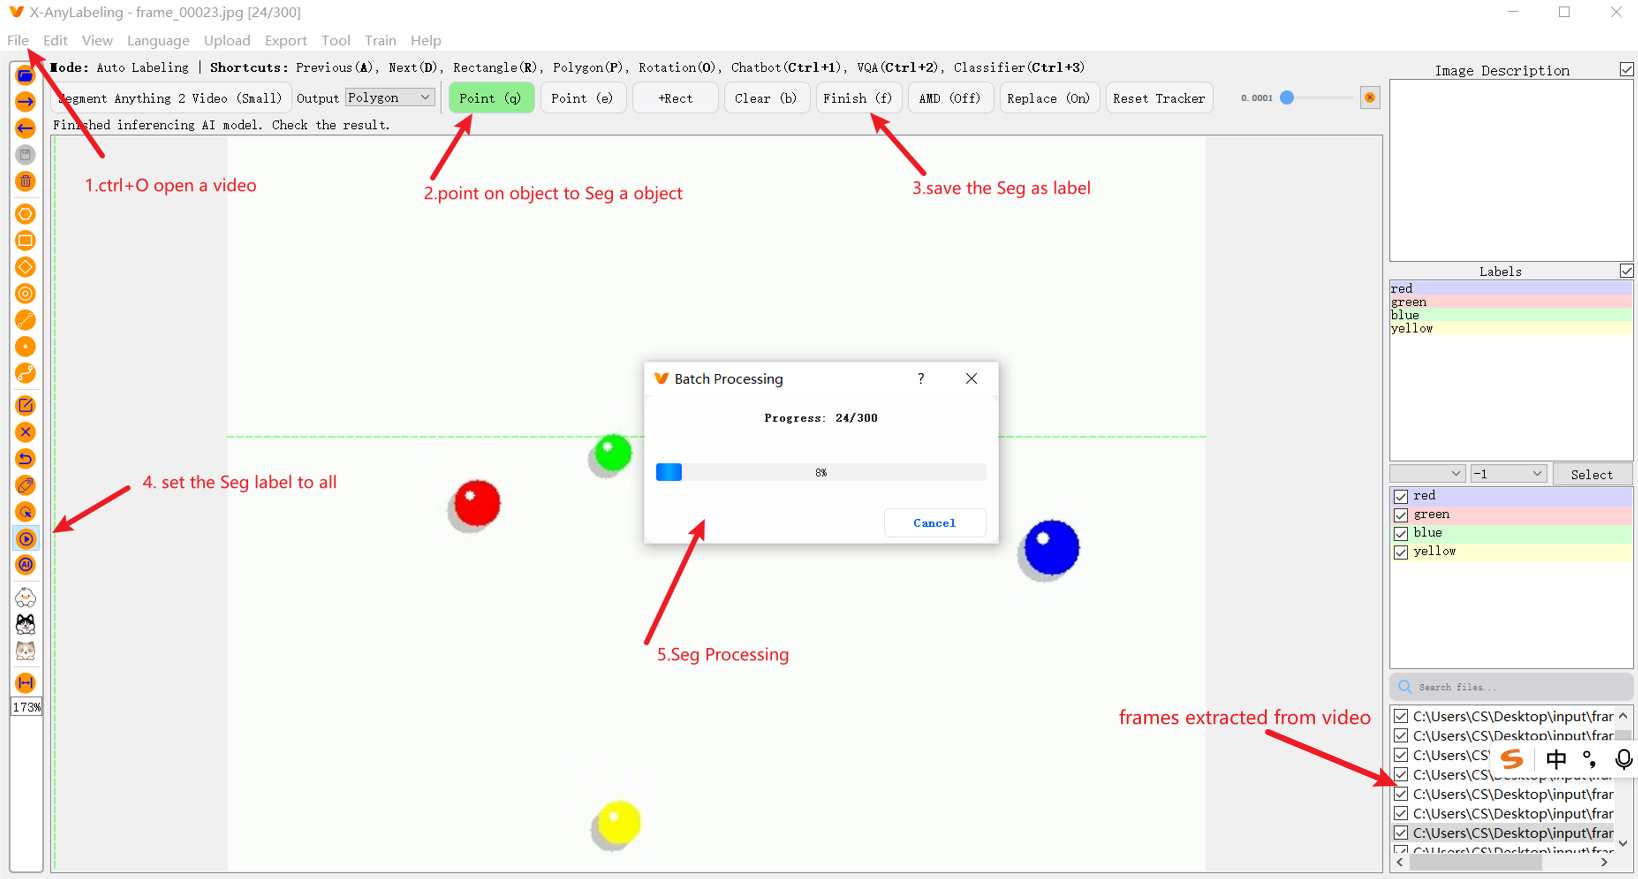


## Troubleshooting

| Issue | Solution |
|-------|----------|
| `No module named 'sam2'` | Re-run Step 3 in the SAM2 directory |
| `cannot import name '_C'` | Install MSVC + CUDA, re-run `build_ext --inplace`  |
| Black video screen | Check file path has no Chinese characters |
| Model not showing | Manually download models (see Manual Setup above)  |